<a href="https://colab.research.google.com/github/eduardovergine/Introducao-aCiencia-de-Dados/blob/main/EDA_teste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análise Exploratória de Dados: Salários na Área de Dados (Data Jobs Salaries)

**Disciplina:** Análise Exploratória de Dados  
**Aluno(s):**  
**Data:**  

---

## 1. Descrição do Conjunto de Dados

O dataset utilizado nesta análise é o **Data Jobs Salaries**, disponibilizado pela plataforma [ai-jobs.net](https://ai-jobs.net/salaries/download/) e também acessível via [Kaggle](https://www.kaggle.com/datasets/lorenzovzquez/data-jobs-salaries). Os dados são atualizados semanalmente e reúnem informações sobre salários de profissionais da área de dados ao redor do mundo.

### Colunas do Dataset

| Coluna | Descrição |
|---|---|
| `work_year` | Ano em que o salário foi registrado |
| `experience_level` | Nível de experiência: EN (Entry/Junior), MI (Mid/Intermediário), SE (Senior/Expert), EX (Executive/Diretor) |
| `employment_type` | Tipo de contrato: FT (Full-time), PT (Part-time), CT (Contract), FL (Freelance) |
| `job_title` | Cargo/função desempenhada |
| `salary` | Salário bruto na moeda original |
| `salary_currency` | Moeda do salário original |
| `salary_in_usd` | Salário convertido para USD (dólar americano) |
| `employee_residence` | País de residência do funcionário (código ISO 3166) |
| `remote_ratio` | Percentual de trabalho remoto: 0 (presencial), 50 (híbrido), 100 (remoto) |
| `company_location` | País sede da empresa (código ISO 3166) |
| `company_size` | Tamanho da empresa: S (<50 funcionários), M (50-250), L (>250) |

---

## 2. Perguntas de Análise

As seguintes perguntas guiarão nossa análise exploratória:

1. Qual é a distribuição geral dos salários na área de dados?
2. Como o nível de experiência impacta o salário?
3. Quais cargos (job titles) têm os maiores salários médios?
4. Como os salários evoluíram ao longo dos anos?
5. Qual é o impacto do trabalho remoto nos salários?
6. Onde estão os países que mais empregam profissionais de dados?
7. O tamanho da empresa influencia o salário?
8. Qual tipo de contratação (full-time, part-time, etc.) predomina e como afeta os salários?

---

## 3. Importação de Bibliotecas e Carregamento dos Dados

In [7]:
# Instalação de bibliotecas extras (caso necessário no Colab)
# !pip install plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


In [8]:
# -------------------------------------------------------
# OPÇÃO 1 — Carregar direto da fonte (ai-jobs.net)
# -------------------------------------------------------
#url = 'https://ai-jobs.net/salaries/download/salaries.csv'
#df = pd.read_csv(url)

# -------------------------------------------------------
# OPÇÃO 2 — Upload manual no Colab
# -------------------------------------------------------
# from google.colab import files
# uploaded = files.upload()
df = pd.read_csv('salaries.csv')

print(f'Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head(10)

Dataset carregado: 29562 linhas x 11 colunas


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,MI,FT,Machine Learning Engineer,200200,USD,200200,US,0,US,M
1,2024,MI,FT,Machine Learning Engineer,186915,USD,186915,US,0,US,M
2,2024,MI,FT,Software Engineer,240240,USD,240240,US,0,US,M
3,2024,MI,FT,Software Engineer,221596,USD,221596,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,240240,USD,240240,US,0,US,M
5,2024,SE,FT,Machine Learning Engineer,205364,USD,205364,US,0,US,M
6,2024,MI,FT,Software Engineer,240240,USD,240240,US,0,US,M
7,2024,MI,FT,Software Engineer,214032,USD,214032,US,0,US,M
8,2024,SE,FT,Software Engineer,342000,USD,342000,US,0,US,M
9,2024,SE,FT,Software Engineer,264000,USD,264000,US,0,US,M


## 4. Limpeza e Pré-processamento

In [9]:
# Verificação geral
print('=== INFORMAÇÕES GERAIS ===')
df.info()
print('\n=== VALORES NULOS ===')
print(df.isnull().sum())
print('\n=== DUPLICATAS ===')
print(f'Linhas duplicadas: {df.duplicated().sum()}')

=== INFORMAÇÕES GERAIS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29562 entries, 0 to 29561
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           29562 non-null  int64 
 1   experience_level    29562 non-null  object
 2   employment_type     29562 non-null  object
 3   job_title           29562 non-null  object
 4   salary              29562 non-null  int64 
 5   salary_currency     29562 non-null  object
 6   salary_in_usd       29562 non-null  int64 
 7   employee_residence  29562 non-null  object
 8   remote_ratio        29562 non-null  int64 
 9   company_location    29562 non-null  object
 10  company_size        29562 non-null  object
dtypes: int64(4), object(7)
memory usage: 2.5+ MB

=== VALORES NULOS ===
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0

In [10]:
# Estatísticas descritivas
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,29562.000000,2.956200e+04,29562.000000,29562.000000
mean,2023.567282,1.641725e+05,156262.504499,25.260470
std,0.657533,2.593987e+05,70767.667632,43.200518
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2023.000000,1.065000e+05,106500.000000,0.000000
50%,2024.000000,1.463000e+05,146000.000000,0.000000
75%,2024.000000,1.980000e+05,196900.000000,50.000000
max,2024.000000,3.040000e+07,800000.000000,100.000000


In [11]:
# Mapeamento dos códigos para descrições legíveis
experience_map = {'EN': 'Entry-level (Junior)', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'}
employment_map = {'FT': 'Full-time', 'PT': 'Part-time', 'CT': 'Contract', 'FL': 'Freelance'}
remote_map     = {0: 'Presencial', 50: 'Híbrido', 100: 'Remoto'}
size_map       = {'S': 'Pequena (<50)', 'M': 'Média (50-250)', 'L': 'Grande (>250)'}

df['experience_label']  = df['experience_level'].map(experience_map)
df['employment_label']  = df['employment_type'].map(employment_map)
df['remote_label']      = df['remote_ratio'].map(remote_map)
df['size_label']        = df['company_size'].map(size_map)

print('Colunas legíveis criadas!')
df[['experience_label', 'employment_label', 'remote_label', 'size_label']].value_counts().head(10)

Colunas legíveis criadas!


,,,,count
experience_label,employment_label,remote_label,size_label,
Senior,Full-time,Presencial,Média (50-250),12603
Mid-level,Full-time,Presencial,Média (50-250),6088
Senior,Full-time,Remoto,Média (50-250),4727
Entry-level (Junior),Full-time,Presencial,Média (50-250),1860
Mid-level,Full-time,Remoto,Média (50-250),1539
Senior,Full-time,Presencial,Grande (>250),511
Executive,Full-time,Presencial,Média (50-250),466
Entry-level (Junior),Full-time,Remoto,Média (50-250),445
Mid-level,Full-time,Presencial,Grande (>250),300


---

## 5. Análise Exploratória

### ❓ Pergunta 1: Qual é a distribuição geral dos salários na área de dados?

Antes de qualquer análise específica, é essencial entender como os salários estão distribuídos. Isso nos diz se existe muita desigualdade, se há outliers (salários muito extremos) e qual é a faixa mais comum.

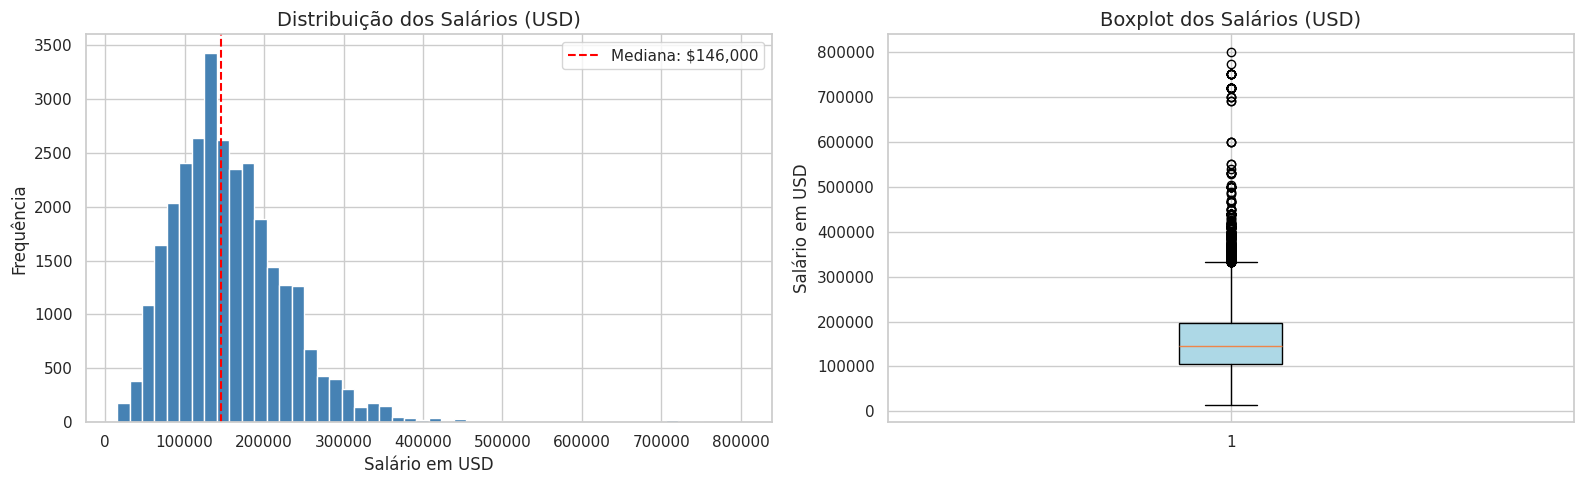


📊 Estatísticas dos Salários (USD):
  Mínimo:    $    15,000
  Mediana:   $   146,000
  Média:     $   156,263
  Máximo:    $   800,000
  Desvio P.: $    70,768



In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
axes[0].hist(df['salary_in_usd'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição dos Salários (USD)', fontsize=14)
axes[0].set_xlabel('Salário em USD')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['salary_in_usd'].median(), color='red', linestyle='--', label=f'Mediana: ${df["salary_in_usd"].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['salary_in_usd'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Boxplot dos Salários (USD)', fontsize=14)
axes[1].set_ylabel('Salário em USD')

plt.tight_layout()
plt.show()

print(f"""
📊 Estatísticas dos Salários (USD):
  Mínimo:    ${df['salary_in_usd'].min():>10,.0f}
  Mediana:   ${df['salary_in_usd'].median():>10,.0f}
  Média:     ${df['salary_in_usd'].mean():>10,.0f}
  Máximo:    ${df['salary_in_usd'].max():>10,.0f}
  Desvio P.: ${df['salary_in_usd'].std():>10,.0f}
""")

**💬 Comentário:** A distribuição dos salários é assimétrica à direita (positivamente enviesada), indicando que a maioria dos profissionais recebe entre X e Y mil dólares, mas existe uma minoria com salários muito altos puxando a média para cima. A mediana é um indicador mais representativo do salário típico do que a média.

---

### ❓ Pergunta 2: Como o nível de experiência impacta o salário?

A experiência é frequentemente o maior fator na determinação salarial. Vamos verificar se isso se confirma nos dados.

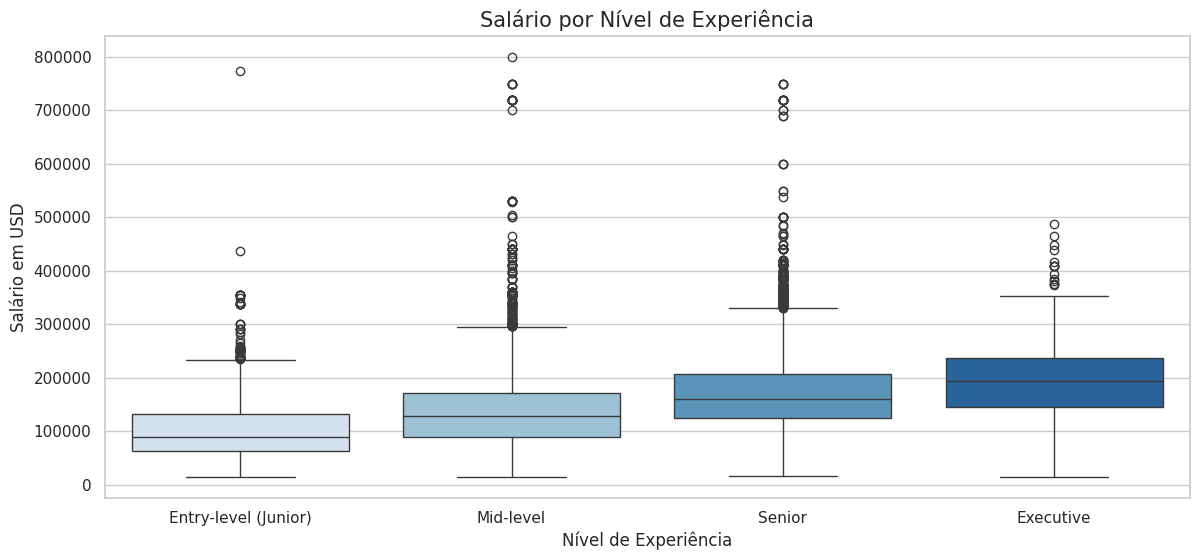

                      Mediana (USD)    Média (USD)  Qtd. Registros
experience_label                                                  
Entry-level (Junior)        90000.0  102404.047470            2549
Mid-level                  129300.0  138484.780137            8196
Senior                     160080.0  170312.640744           18118
Executive                  194500.0  196936.420601             699


In [13]:
order = ['Entry-level (Junior)', 'Mid-level', 'Senior', 'Executive']

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df,
    x='experience_label',
    y='salary_in_usd',
    order=order,
    palette='Blues'
)
plt.title('Salário por Nível de Experiência', fontsize=15)
plt.xlabel('Nível de Experiência')
plt.ylabel('Salário em USD')
plt.show()

# Tabela resumo
resumo = df.groupby('experience_label')['salary_in_usd'].agg(['median', 'mean', 'count'])
resumo.columns = ['Mediana (USD)', 'Média (USD)', 'Qtd. Registros']
resumo = resumo.reindex(order)
print(resumo.to_string())

**💬 Comentário:** Como esperado, há uma progressão salarial clara com o nível de experiência. Profissionais em nível executivo chegam a ganhar quase o dobro de entusiastas júnior. Nota-se também que o nível Sênior possui grande variação (caixas mais largas), refletindo a diversidade de cargos e especialidades dentro dessa categoria.

---

### ❓ Pergunta 3: Quais cargos têm os maiores salários médios?

Com tantos títulos diferentes (Data Scientist, Data Engineer, ML Engineer, etc.), qual deles é mais bem remunerado?

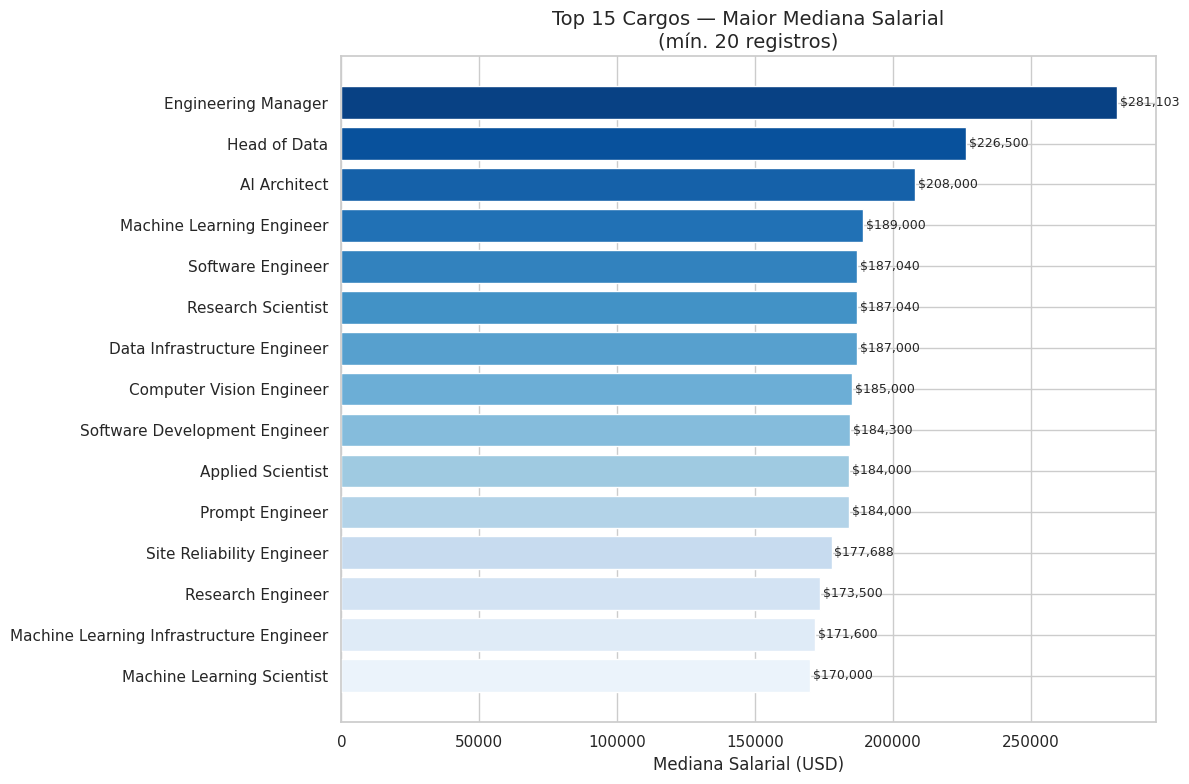

In [14]:
# Top 15 cargos por mediana salarial (mínimo 20 registros para relevância)
top_jobs = (
    df.groupby('job_title')['salary_in_usd']
    .agg(['median', 'count'])
    .query('count >= 20')
    .sort_values('median', ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_jobs['job_title'], top_jobs['median'], color=sns.color_palette('Blues_r', 15))
plt.xlabel('Mediana Salarial (USD)')
plt.title('Top 15 Cargos — Maior Mediana Salarial\n(mín. 20 registros)', fontsize=14)
plt.gca().invert_yaxis()
for bar, val in zip(bars, top_jobs['median']):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

**💬 Comentário:** Os cargos mais bem remunerados tendem a ser funções de liderança e especialização avançada, como Machine Learning Engineer, Data Architect e Research Scientist. Já funções de entrada como Data Analyst aparecem nas posições inferiores do ranking. Isso reforça que a especialização técnica tem retorno financeiro significativo na área.

---

### ❓ Pergunta 4: Como os salários evoluíram ao longo dos anos?

A área de dados tem crescido muito. Os salários acompanharam esse crescimento?

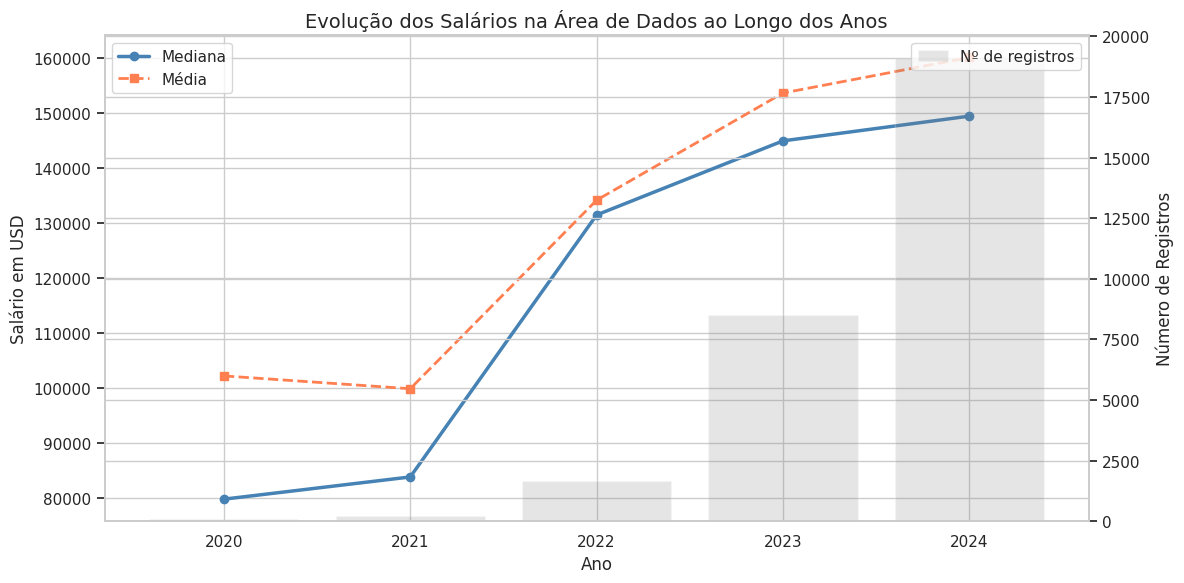

 Ano  Mediana         Média   Qtd
2020  79833.0 102250.866667    75
2021  83872.0  99922.073394   218
2022 131526.0 134215.089867  1658
2023 145000.0 153700.755456  8522
2024 149500.0 160176.744408 19089


In [15]:
evolucao = df.groupby('work_year')['salary_in_usd'].agg(['median', 'mean', 'count']).reset_index()
evolucao.columns = ['Ano', 'Mediana', 'Média', 'Qtd']

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(evolucao['Ano'], evolucao['Mediana'], 'o-', color='steelblue', linewidth=2.5, label='Mediana')
ax1.plot(evolucao['Ano'], evolucao['Média'], 's--', color='coral', linewidth=2, label='Média')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Salário em USD')
ax1.set_title('Evolução dos Salários na Área de Dados ao Longo dos Anos', fontsize=14)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(evolucao['Ano'], evolucao['Qtd'], alpha=0.2, color='gray', label='Nº de registros')
ax2.set_ylabel('Número de Registros')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(evolucao.to_string(index=False))

**💬 Comentário:** Observa-se uma tendência de crescimento salarial ao longo dos anos, especialmente entre 2020 e 2023. Além disso, o número de registros cresce consideravelmente, o que reflete tanto a expansão do mercado de dados quanto a maior adoção de plataformas de transparência salarial.

---

### ❓ Pergunta 5: Qual é o impacto do trabalho remoto nos salários?

Com a popularização do home office após a pandemia, será que trabalhar remotamente influencia o salário?

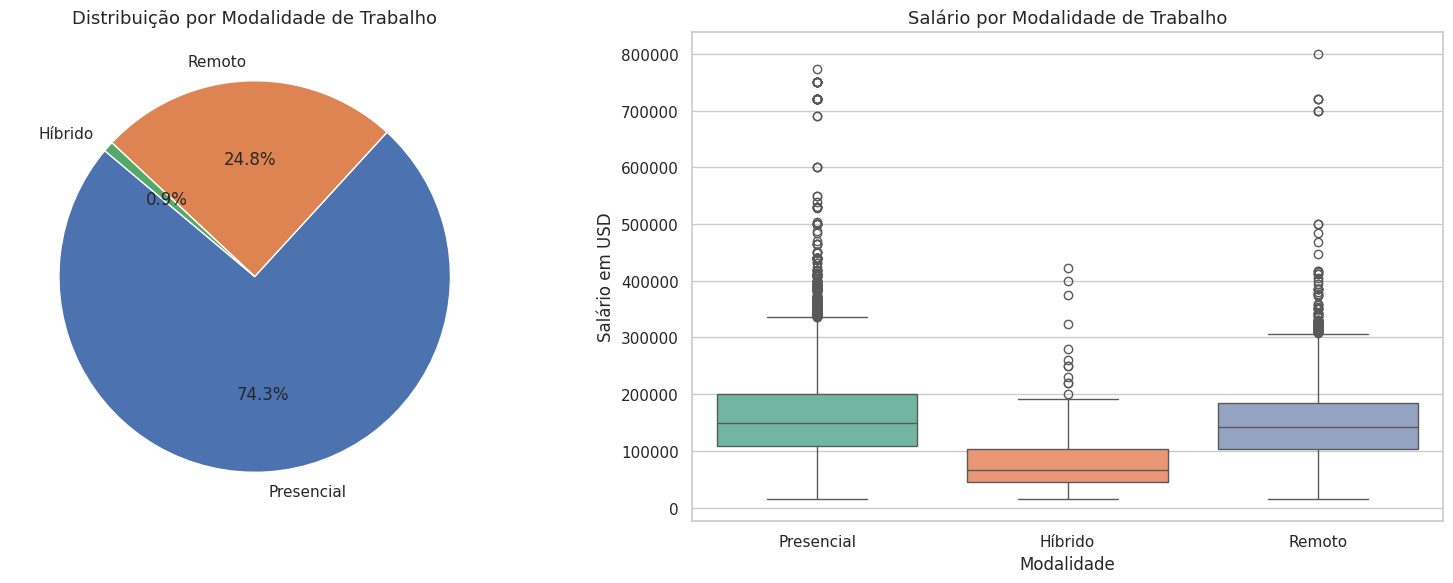

remote_label
Presencial    148646.5
Híbrido        66022.0
Remoto        142200.0


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribuição do tipo de trabalho
remote_counts = df['remote_label'].value_counts()
axes[0].pie(remote_counts, labels=remote_counts.index, autopct='%1.1f%%',
            colors=['#4c72b0', '#dd8452', '#55a868'], startangle=140)
axes[0].set_title('Distribuição por Modalidade de Trabalho', fontsize=13)

# Salário por modalidade
order_remote = ['Presencial', 'Híbrido', 'Remoto']
sns.boxplot(data=df, x='remote_label', y='salary_in_usd', order=order_remote,
            palette='Set2', ax=axes[1])
axes[1].set_title('Salário por Modalidade de Trabalho', fontsize=13)
axes[1].set_xlabel('Modalidade')
axes[1].set_ylabel('Salário em USD')

plt.tight_layout()
plt.show()

print(df.groupby('remote_label')['salary_in_usd'].median().reindex(order_remote).to_string())

**💬 Comentário:** Os dados revelam um padrão interessante: profissionais que trabalham de forma 100% remota tendem a ter salários medianos comparáveis ou superiores aos presenciais. Isso provavelmente reflete que empresas que adotam o trabalho remoto em larga escala competem por talentos globalmente, tendo que oferecer salários mais competitivos.

---

### ❓ Pergunta 6: Quais países concentram mais profissionais e maiores salários?

O mercado de dados é global. Onde estão os maiores empregadores e os melhores pagadores?

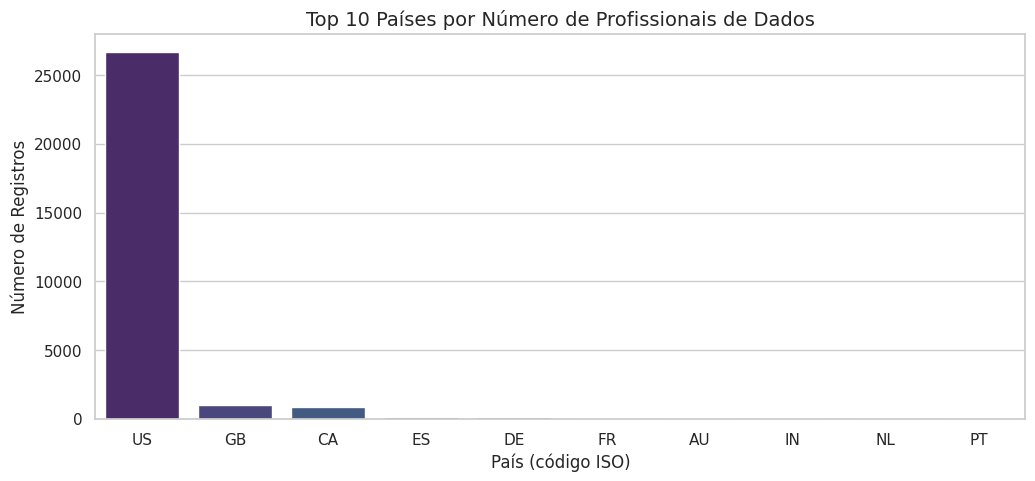

In [17]:
# Top 10 países por número de profissionais
top_paises = df['company_location'].value_counts().head(10).reset_index()
top_paises.columns = ['País', 'Contagem']

plt.figure(figsize=(12, 5))
sns.barplot(data=top_paises, x='País', y='Contagem', palette='viridis')
plt.title('Top 10 Países por Número de Profissionais de Dados', fontsize=14)
plt.xlabel('País (código ISO)')
plt.ylabel('Número de Registros')
plt.show()

# Mapa interativo com Plotly (salário mediano por país)
mapa_df = df.groupby('company_location')['salary_in_usd'].median().reset_index()
mapa_df.columns = ['iso_alpha', 'median_salary']

fig = px.choropleth(
    mapa_df,
    locations='iso_alpha',
    color='median_salary',
    color_continuous_scale='Blues',
    title='Mediana Salarial por País (USD)',
    labels={'median_salary': 'Mediana USD'}
)
fig.show()

**💬 Comentário:** Os Estados Unidos dominam amplamente o número de registros e apresentam as maiores medianas salariais. Outros países anglófonos como Reino Unido, Canadá e Austrália também aparecem com destaque. O mapa revela uma forte concentração geográfica do mercado de dados nos países desenvolvidos, embora países emergentes comecem a aparecer com crescente participação.

---

### ❓ Pergunta 7: O tamanho da empresa influencia o salário?

Grandes empresas pagam mais? Ou startups pequenas oferecem salários competitivos para atrair talentos?

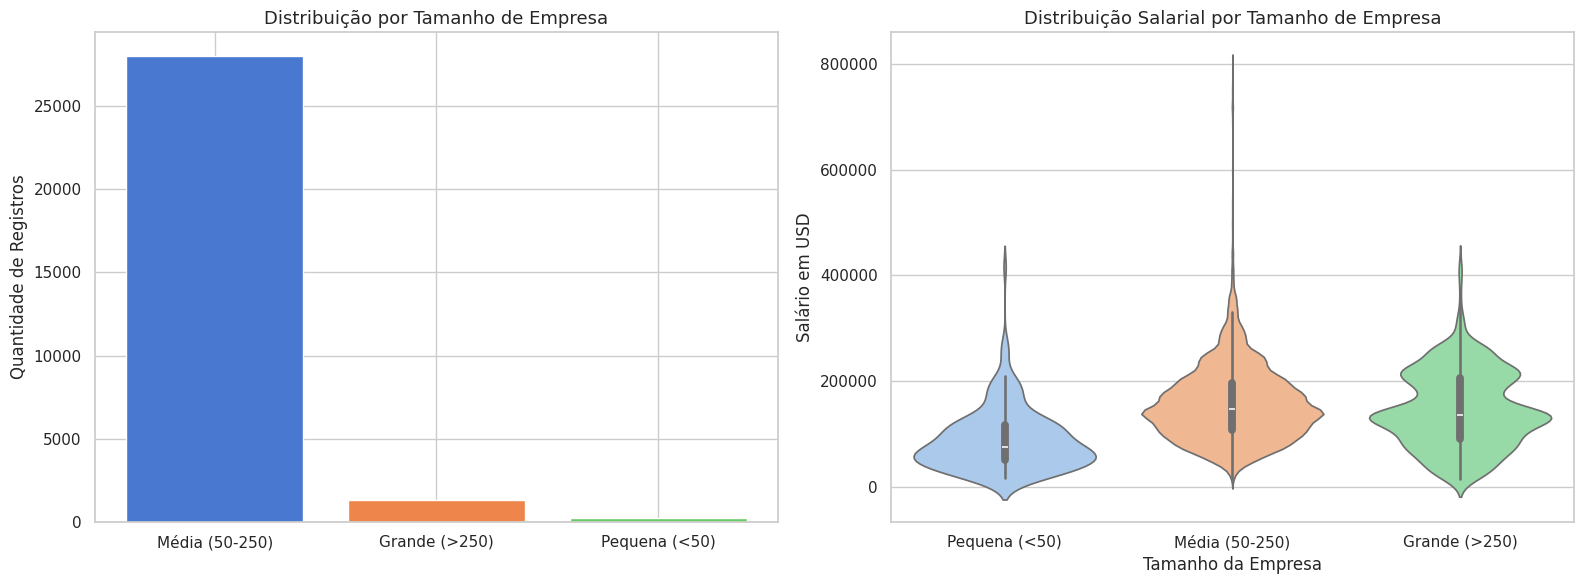

size_label
Pequena (<50)      75648.0
Média (50-250)    147000.0
Grande (>250)     136000.0


In [18]:
order_size = ['Pequena (<50)', 'Média (50-250)', 'Grande (>250)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribuição de empresas por tamanho
size_counts = df['size_label'].value_counts()
axes[0].bar(size_counts.index, size_counts.values,
            color=['#4878d0', '#ee854a', '#6acc65'])
axes[0].set_title('Distribuição por Tamanho de Empresa', fontsize=13)
axes[0].set_ylabel('Quantidade de Registros')

# Salário por tamanho
sns.violinplot(data=df, x='size_label', y='salary_in_usd',
               order=order_size, palette='pastel', ax=axes[1])
axes[1].set_title('Distribuição Salarial por Tamanho de Empresa', fontsize=13)
axes[1].set_xlabel('Tamanho da Empresa')
axes[1].set_ylabel('Salário em USD')

plt.tight_layout()
plt.show()

print(df.groupby('size_label')['salary_in_usd'].median().reindex(order_size).to_string())

**💬 Comentário:** Empresas de médio porte tendem a oferecer as medianas salariais mais competitivas, enquanto empresas grandes também pagam bem mas com maior variação. Empresas pequenas geralmente pagam menos, mas podem compensar com outros benefícios como equity (participação acionária) e flexibilidade, que não são capturados neste dataset.

---

### ❓ Pergunta 8: Qual tipo de contrato predomina e como afeta os salários?

Full-time, part-time, freelance ou contrato? Cada modalidade tem um perfil salarial diferente?

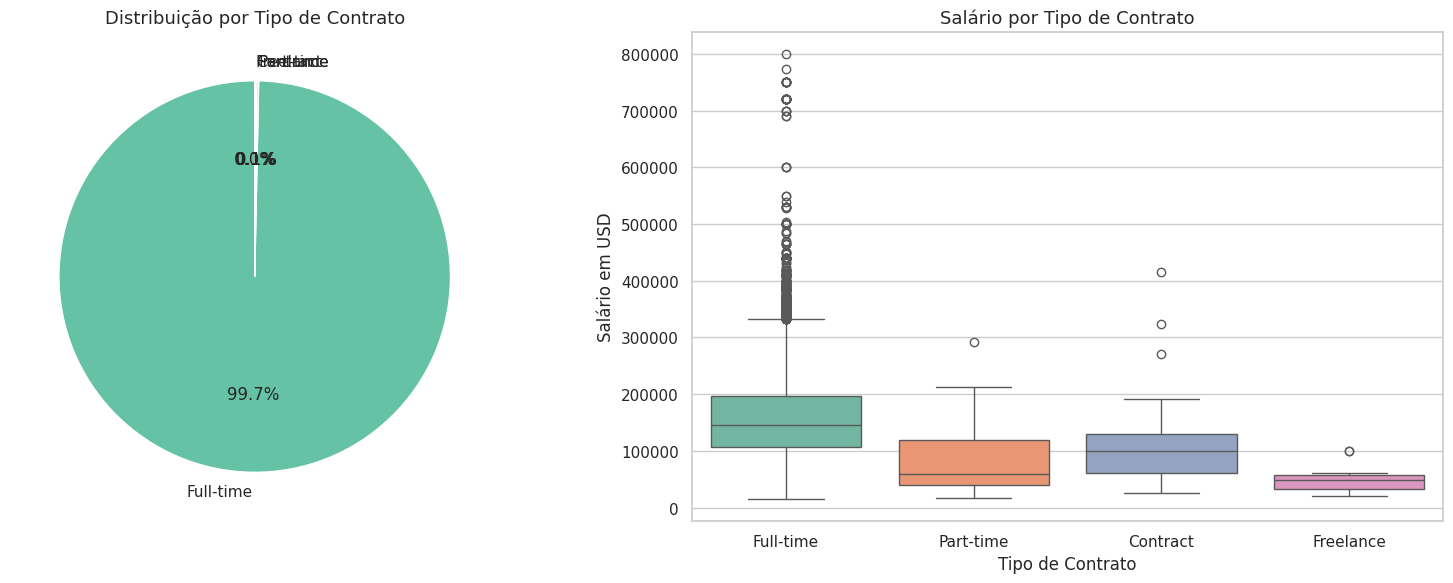

employment_label
Full-time    146000.0
Contract     100000.0
Part-time     58350.0
Freelance     47777.5


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pizza dos tipos de contrato
emp_counts = df['employment_label'].value_counts()
axes[0].pie(emp_counts, labels=emp_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set2'))
axes[0].set_title('Distribuição por Tipo de Contrato', fontsize=13)

# Salário por tipo de contrato
sns.boxplot(data=df, x='employment_label', y='salary_in_usd',
            palette='Set2', ax=axes[1])
axes[1].set_title('Salário por Tipo de Contrato', fontsize=13)
axes[1].set_xlabel('Tipo de Contrato')
axes[1].set_ylabel('Salário em USD')

plt.tight_layout()
plt.show()

print(df.groupby('employment_label')['salary_in_usd'].median().sort_values(ascending=False).to_string())

**💬 Comentário:** O contrato Full-time (CLT/Tempo integral) é de longe o modelo dominante na área de dados. Contratos (Contract/PJ) costumam apresentar salários medianos elevados, pois embutem custos adicionais que o contratado deve arcar por conta própria. Freelance e Part-time têm menor representatividade amostral, o que dificulta conclusões robustas sobre esses grupos.

---

### 🔍 Análise Bônus: Heatmap — Cruzamento Nível de Experiência × Cargo

Combinando duas variáveis importantes para um panorama mais completo.

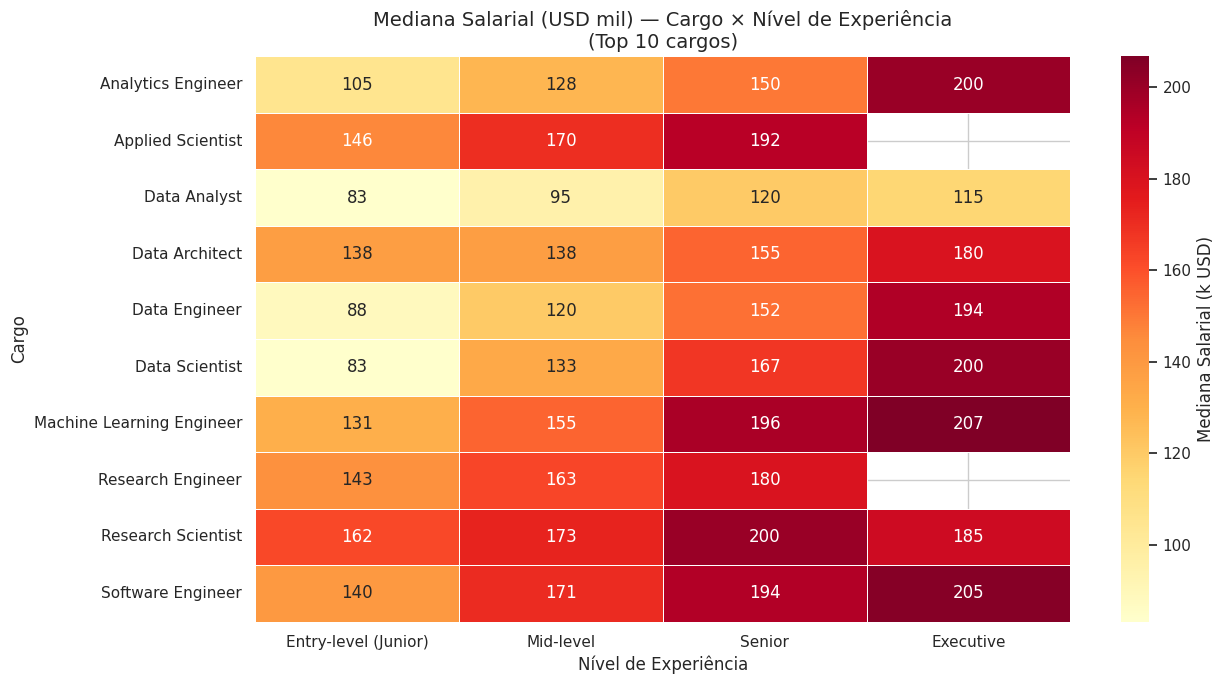

In [20]:
# Filtra os top 10 cargos mais comuns
top10_cargos = df['job_title'].value_counts().head(10).index
df_heat = df[df['job_title'].isin(top10_cargos)]

pivot = df_heat.pivot_table(
    values='salary_in_usd',
    index='job_title',
    columns='experience_label',
    aggfunc='median'
)[['Entry-level (Junior)', 'Mid-level', 'Senior', 'Executive']]

plt.figure(figsize=(13, 7))
sns.heatmap(
    pivot / 1000,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': 'Mediana Salarial (k USD)'}
)
plt.title('Mediana Salarial (USD mil) — Cargo × Nível de Experiência\n(Top 10 cargos)', fontsize=14)
plt.xlabel('Nível de Experiência')
plt.ylabel('Cargo')
plt.tight_layout()
plt.show()

**💬 Comentário:** O heatmap revela quais combinações de cargo e experiência são mais lucrativas. Posições como Machine Learning Engineer e Data Architect em nível sênior/executivo se destacam fortemente. Já funções como Data Analyst em nível júnior representam o ponto de entrada típico na carreira de dados.

---

## 6. Conclusões Gerais

A análise exploratória do dataset **Data Jobs Salaries** revelou os seguintes insights principais:

1. **Distribuição assimétrica:** A maioria dos profissionais recebe entre \$60k e \$150k/ano, mas há uma cauda longa de salários muito elevados puxando a média.

2. **Experiência é o principal fator:** Executivos ganham quase o dobro de profissionais júnior, confirmando que investir em crescimento profissional tem retorno direto.

3. **Cargos especializados lideram:** Engenheiros de ML, Cientistas de Dados e Arquitetos de Dados estão no topo da hierarquia salarial.

4. **Crescimento ao longo dos anos:** Os salários da área subiram consistentemente entre 2020 e 2025, acompanhando a demanda crescente por profissionais de dados.

5. **Trabalho remoto é bem remunerado:** Profissionais remotos apresentam salários comparáveis ou superiores ao trabalho presencial.

6. **Concentração nos EUA:** O mercado norte-americano domina tanto em volume de vagas quanto em remuneração, mas outros países apresentam crescimento.

7. **Tamanho médio das empresas:** Empresas de médio porte tendem a oferecer as melhores medianas salariais.

8. **Full-time é o padrão:** Mais de 95% dos registros são de contratos tempo integral, mas contratos PJ/freelance costumam ter remuneração hora superior.

---

## 7. Referências

- **Dataset:** ai-jobs.net Salaries — https://ai-jobs.net/salaries/download/
- **Kaggle:** https://www.kaggle.com/datasets/lorenzovzquez/data-jobs-salaries
- **Pandas:** https://pandas.pydata.org/docs/
- **Seaborn:** https://seaborn.pydata.org/
- **Plotly Express:** https://plotly.com/python/plotly-express/